In [70]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Subplot
import seaborn as sns

In [71]:
df_raw = pd.read_csv("Telco-customer-Churn.csv  ")
print(f"Shape: {df_raw.shape[0]:,} columns and {df_raw.shape[1]:,} rows")
df_raw.head()

Shape: 7,043 columns and 21 rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [72]:
print("Missing values")
print(df_raw.isnull().sum())
print()
print("Duplicates")
print(df_raw.duplicated().sum())
print()
print("Data types")
print(df_raw.dtypes)

Missing values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicates
0

Data types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentM

In [73]:
print("Unique values for cetain columns:")
for col in df_raw.columns:
    if col in ['customerID', 'MonthlyCharges', 'TotalCharges', 'tenure']:
        pass
    else:
        print(col)
        print(df_raw[col].value_counts())

Unique values for cetain columns:
gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
DeviceProtection
No                     3095
Yes                    

In [74]:
#convert Totalcharges from object to numeric and fill all empty rows with 0
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
df_raw['TotalCharges'] = df_raw['TotalCharges'].fillna(0)
print(f"Number of null rows in df_raw: {df_raw['TotalCharges'].isnull().sum()}")

Number of null rows in df_raw: 0


In [75]:
#convert SeniorCitizen which is a binary column to Yes/No like similar columns
df_raw['SeniorCitizen'] = df_raw['SeniorCitizen'].map({0: "No", 1: "Yes"})
print(f"New values for SeniorCitizen Column: {df_raw['SeniorCitizen'].head(1)}")

New values for SeniorCitizen Column: 0    No
Name: SeniorCitizen, dtype: object


In [76]:
df_raw['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [77]:
#convert target column from object to numeric for the binary classifier
#Option1
df_raw['Churn'] = (df_raw['Churn'] == 'Yes').astype(int)
print(df_raw['Churn'].value_counts())

#Option2
# df_raw['Churn'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})
# df_raw['Churn'] = pd.to_numeric(df_raw['Churn'], errors='coerce')

print(df_raw['Churn'].dtype)

Churn
0    5174
1    1869
Name: count, dtype: int64
int64


In [78]:
#lets determine the churn rate
churn_rate = df_raw['Churn'].mean() * 100
print(churn_rate)

26.536987079369588


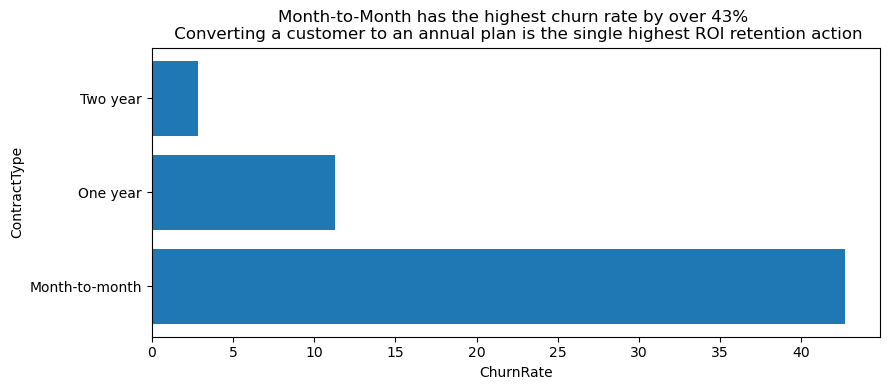

Bussiness insight
Month-to-Month has the biggest churn rate of 
                ChurnRate  CustomerCount  ChurnRate_pct
Contract                                               
Month-to-month   0.427097           3875      42.709677
One year         0.112695           1473      11.269518
Two year         0.028319           1695       2.831858


In [79]:
contract_churn = (
    df_raw.groupby('Contract')['Churn']
    .agg(['mean', 'count'])
    .rename(columns={"mean": "ChurnRate", "count": "CustomerCount"})
    .sort_values('ChurnRate', ascending=False)
    )
contract_churn['ChurnRate_pct'] = contract_churn['ChurnRate'] * 100
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(contract_churn.index, contract_churn['ChurnRate_pct'])
ax.set_xlabel("ChurnRate")
ax.set_ylabel("ContractType")
ax.set_title("Month-to-Month has the highest churn rate by over 43% \n Converting a customer to an annual plan is the single highest ROI retention action")
plt.tight_layout()
plt.show()

print("Bussiness insight")
print("Month-to-Month has the biggest churn rate of ")
print(contract_churn)

In [80]:
# customerchurn = (
#     df_raw.groupby('Contract')['Churn']
#     .agg(['mean', 'count'])
#     .rename(columns={"mean": "ChurnRate", "count": "CustomerCount"})
#     .sort_values('ChurnRate', ascending=False)
# )
# customerchurn['ChurnRate-pct'] = customerchurn['ChurnRate'] * 100

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.barh(customerchurn.index, customerchurn['ChurnRate-pct'])
# ax.set_xlim(0, 60)
# plt.show()
# print(customerchurn.index)
# print(customerchurn.values)
# print(customerchurn)

In [81]:
bins = [0, 6, 12, 24, 36,60, 72]
labels = ['0-6m', '7-12m', '13-24m','25-36m',  '37-60m', '61-72m']

df_raw['TenureBucket'] = pd.cut(df_raw['tenure'], bins=bins, labels=labels)

TenureBucket
0-6m      53.333333
7-12m     35.886525
13-24m    28.710938
25-36m    21.634615
37-60m    16.624843
61-72m     6.609808
Name: Churn, dtype: float64


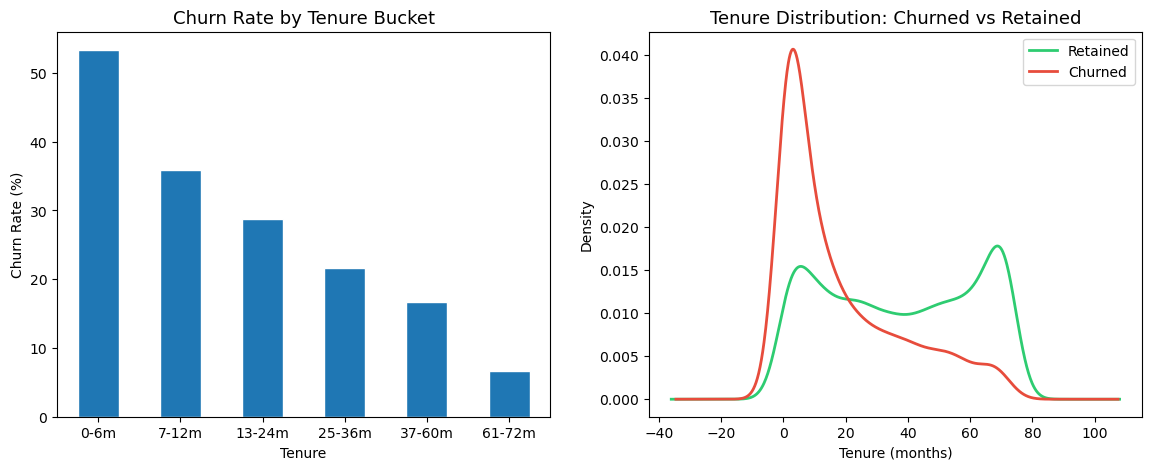

Business Insight:
  Most churners leave in the first 12 months.
  Retention campaigns should be front-loaded for new customers, not loyal ones.


In [82]:

tenure_churn = df_raw.groupby("TenureBucket")['Churn'].mean() * 100
print(tenure_churn)
fig, axes = plt.subplots(1, 2,figsize=(14, 5))

tenure_churn.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Churn Rate by Tenure Bucket', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Tenure')
axes[0].tick_params(axis='x', rotation=0)

df_raw[df_raw['Churn'] == 0]['tenure'].plot(
    kind='kde', ax=axes[1], label="Retained", color='#2ecc71', linewidth=2
)
df_raw[df_raw['Churn']== 1]["tenure"].plot(
    kind="kde", label='Churned', linewidth=2, color='#e74c3c'
)
axes[1].legend()
axes[1].set_title('Tenure Distribution: Churned vs Retained', fontsize=13)
axes[1].set_xlabel('Tenure (months)')
plt.show()
print('Business Insight:')
print('  Most churners leave in the first 12 months.')
print('  Retention campaigns should be front-loaded for new customers, not loyal ones.')


In [83]:
bins = [0, 6, 12, 24, 36, 60, 72]
labels_t = ["0-6m", "7-12m", "13-24m", "25-36m", "37-60m", "61-72m"]

tenure_buckets = (
    pd.cut(df_raw['tenure'], bins=bins, labels=labels_t)
)
df_raw['TenureBucket'] = tenure_buckets


TenureBucket
0-6m      53.333333
7-12m     35.886525
13-24m    28.710938
25-36m    21.634615
37-60m    16.624843
61-72m     6.609808
Name: Churn, dtype: float64


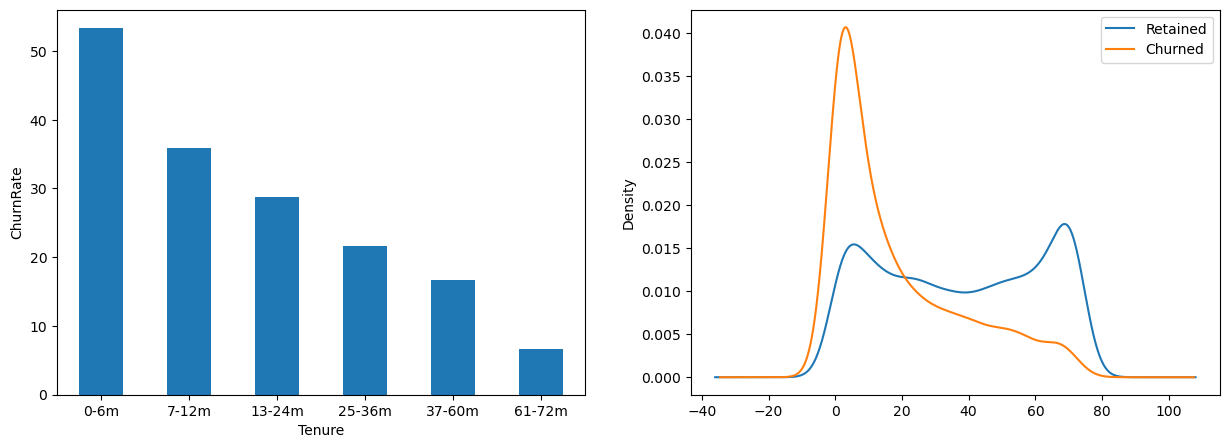

In [84]:
tenure_churn = df_raw.groupby('TenureBucket')['Churn'].mean() * 100
print(tenure_churn)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tenure_churn.plot(kind="bar", ax=axes[0] )
axes[0].set_xlabel("Tenure")
axes[0].set_ylabel("ChurnRate")
axes[0].tick_params(axis="x", rotation=0)

df_raw[df_raw['Churn'] == 0]['tenure'].plot(kind='kde', ax=axes[1], label='Retained')
df_raw[df_raw['Churn'] == 1]['tenure'].plot(kind='kde', ax=axes[1], label="Churned")
axes[1].legend()
plt.show()

In [85]:
# print(df_raw['TenureBucket'].unique())
# print(df_raw[df_raw['TenureBucket'].isna()])

In [86]:
# df_raw.info()
# df_raw.to_csv('Telco-Customer-Churn-Cleaned.csv', index=False)

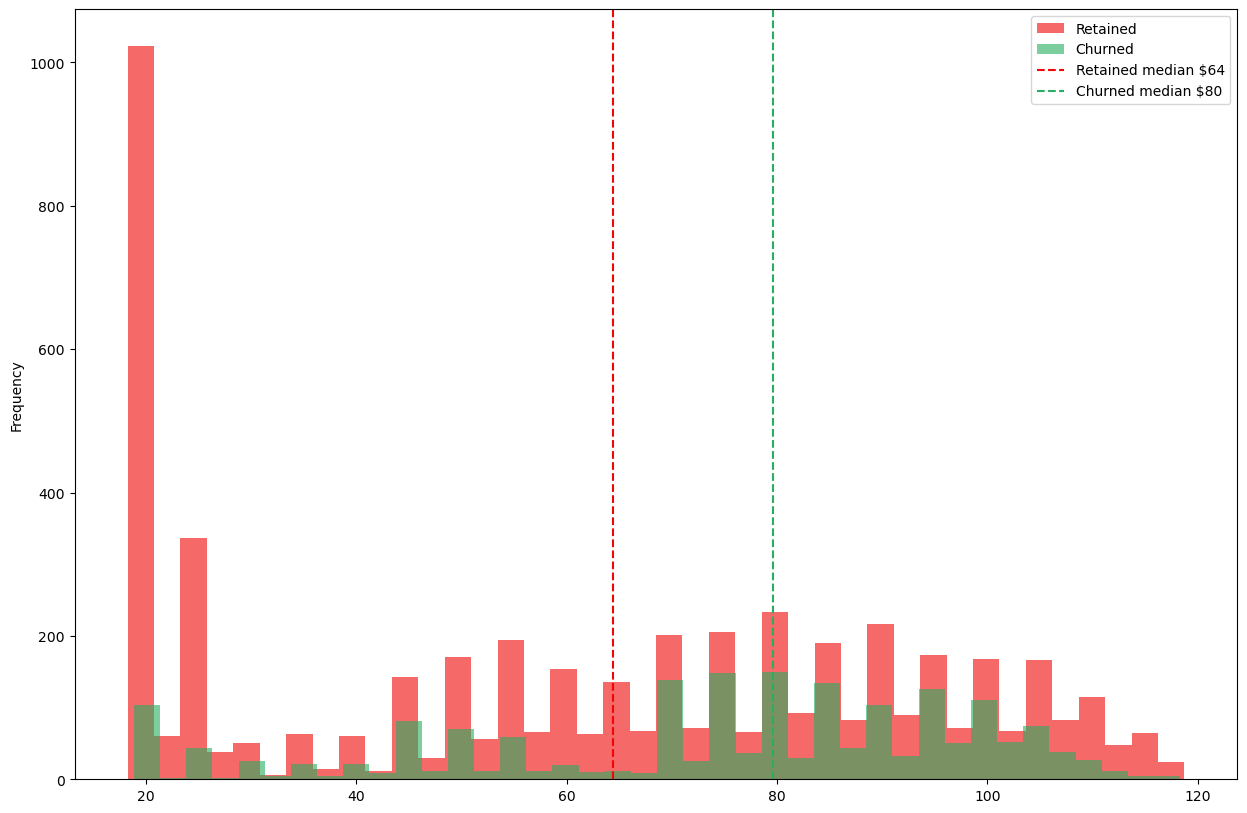

Churned customers give $16 more than the retained customers


In [87]:
fig, ax = plt.subplots(figsize=(15, 10))

df_raw[df_raw['Churn'] == 0]['MonthlyCharges'].plot(kind='hist', bins=40, alpha=0.6, label="Retained", color="#f10505")
df_raw[df_raw['Churn'] == 1]['MonthlyCharges'].plot(
    kind="hist", bins=40, alpha=0.6, label="Churned",  color="#27ae60"
)

retained_median = df_raw[df_raw['Churn'] == 0]['MonthlyCharges'].median()
churned_median = df_raw[df_raw['Churn'] == 1]['MonthlyCharges'].median()

ax.axvline(retained_median,label=f"Retained median ${retained_median:.0f}", linestyle="--",  color="#f10505")
ax.axvline(churned_median,label=f"Churned median ${churned_median:.0f}", linestyle="--", color="#27ae60")
ax.legend()
plt.show()

print("Churned customers give $16 more than the retained customers")


In [88]:
# print(len(cat_cols))

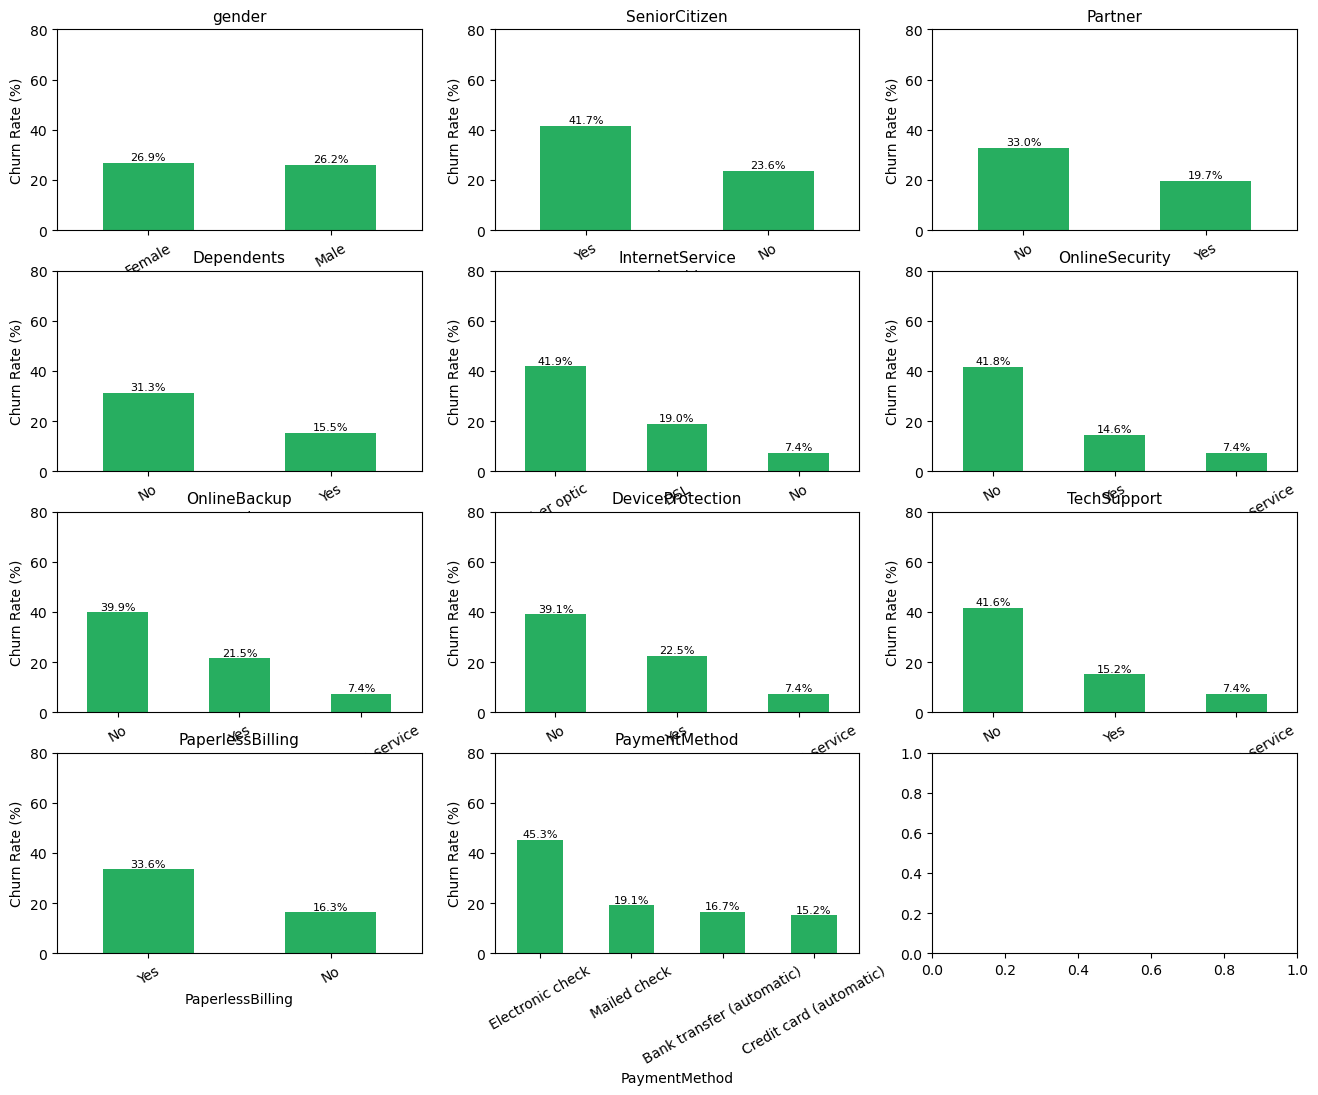

In [89]:
cat_cols = (df_raw.select_dtypes('object').columns.drop(['customerID', 'PhoneService', 'MultipleLines', 'StreamingMovies', 'StreamingTV', 'Contract'])).to_list()

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_by_col = (
        df_raw.groupby(col)['Churn'].mean() * 100
    ).sort_values(ascending=False)
    churn_by_col.plot(kind='bar', ax=axes[i], color="#27ae60")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylim(0, 80)
    for p in axes[i].patches:
            axes[i].annotate(
                f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 1),
                ha='center', fontsize=8
            )

In [90]:
# =============================================================
# CELL 10 — FEATURE ENGINEERING
#
# We create 7 new features from domain logic:
#
# 1. AvgMonthlySpend    — TotalCharges/tenure (true average bill;
#                          deviations from MonthlyCharges signal promotions)
# 2. NumAddons          — count of add-on services; more addons =
#                          more embedded in ecosystem = less likely to leave
# 3. IsBundled          — has both phone AND internet (higher switching cost)
# 4. IsAutopay          — autopay customers rarely cancel (need deliberate action)
# 5. ContractCommitment — maps contract type to months of commitment (0/12/24)
# 6. ChargePerAddon     — monthly cost divided by addons (low value -> churn risk)
# 7. HighChurnRiskPayment — paperless billing + electronic check = double risk flag
# =============================================================

df = df_raw.copy()   # ALWAYS work on a copy; never mutate the raw data

# Feature 1: true average monthly spend (catches plan-change signals)
df['AvgMonthlySpend'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']   # for tenure=0 use current charge as proxy
)

# Feature 2: number of add-on services subscribed
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumAddons'] = df[addon_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

# Feature 3: bundle flag (phone + internet = high switching cost)
df['IsBundled'] = (
    (df['PhoneService'] == 'Yes') &
    (df['InternetService'].isin(['DSL', 'Fiber optic']))
).astype(int)

# Feature 4: autopay flag (manual payment = easier to forget/cancel)
df['IsAutopay'] = df['PaymentMethod'].str.contains('automatic').astype(int)

# Feature 5: contract commitment in months (ordinal encoding with real-world meaning)
contract_commitment = {'Month-to-month': 0, 'One year': 12, 'Two year': 24}
df['ContractCommitment'] = df['Contract'].map(contract_commitment)

# Feature 6: monthly cost per add-on (+1 avoids division by zero)
df['ChargePerAddon'] = df['MonthlyCharges'] / (df['NumAddons'] + 1)

# Feature 7: paperless billing AND electronic check = maximum churn risk payment profile
df['HighChurnRiskPayment'] = (
    (df['PaperlessBilling'] == 'Yes') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

new_feats = ['AvgMonthlySpend', 'NumAddons', 'IsBundled',
             'IsAutopay', 'ContractCommitment', 'ChargePerAddon', 'HighChurnRiskPayment']
print('New engineered features (first 5 rows):')
df[new_feats + ['Churn']].head()


New engineered features (first 5 rows):


,AvgMonthlySpend,NumAddons,IsBundled,IsAutopay,ContractCommitment,ChargePerAddon,HighChurnRiskPayment,Churn
0,29.850000,1,0,0,0,14.925000,1,0
1,55.573529,2,1,0,12,18.983333,0,0
2,54.075000,2,1,0,0,17.950000,0,1
3,40.905556,3,0,1,12,10.575000,0,0
4,75.825000,0,1,0,0,70.700000,1,1


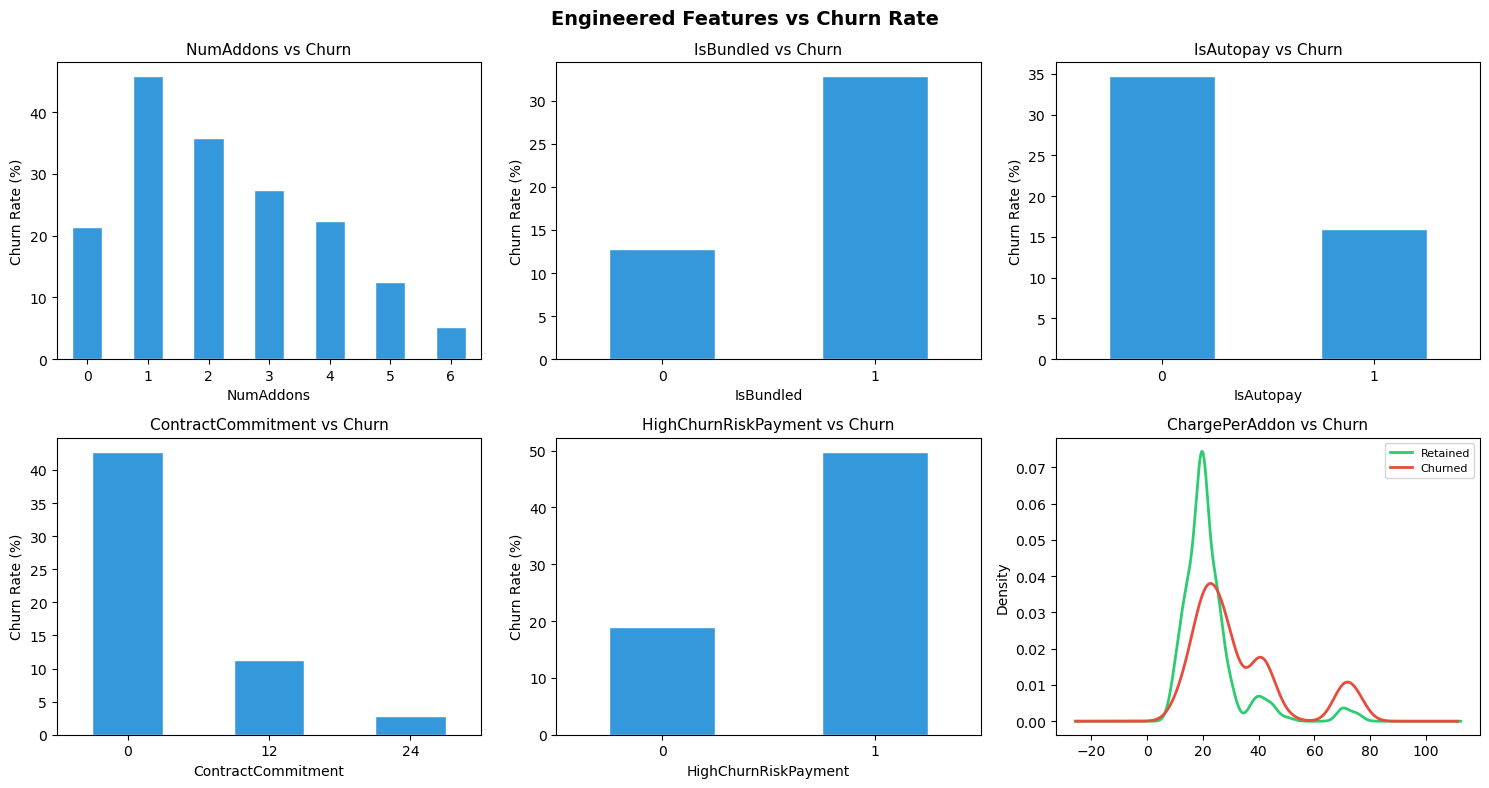

All engineered features show meaningful churn signal -- worth keeping!


In [91]:
# =============================================================
# CELL 11 — VALIDATE ENGINEERED FEATURES AGAINST CHURN
#
# Before trusting a feature, verify it actually varies with the target.
# A feature with no relationship to Churn adds noise and can HURT
# model performance.
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_feats = [
    ('NumAddons',            'bar'),
    ('IsBundled',            'bar'),
    ('IsAutopay',            'bar'),
    ('ContractCommitment',   'bar'),
    ('HighChurnRiskPayment', 'bar'),
    ('ChargePerAddon',       'kde'),
]

for i, (feat, plot_type) in enumerate(plot_feats):
    ax = axes[i]
    if plot_type == 'bar':
        churn_by_feat = (df.groupby(feat)['Churn'].mean() * 100).sort_index()
        churn_by_feat.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
        ax.set_ylabel('Churn Rate (%)')
        ax.tick_params(axis='x', rotation=0)
    else:
        df[df['Churn'] == 0][feat].plot(
            kind='kde', ax=ax, color='#2ecc71', label='Retained', linewidth=2)
        df[df['Churn'] == 1][feat].plot(
            kind='kde', ax=ax, color='#e74c3c', label='Churned',  linewidth=2)
        ax.legend(fontsize=8)
    ax.set_title(f'{feat} vs Churn', fontsize=11)

plt.suptitle('Engineered Features vs Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('All engineered features show meaningful churn signal -- worth keeping!')


In [92]:
from sklearn.model_selection import train_test_split

DROP_COLS = ['customerID', 'Churn', 'TenureBucket', 'TotalCharges']

X = df.drop(columns=DROP_COLS)
y = df['Churn']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_model = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features ( {len(num_cols)}): ')
print(num_cols)
print(f'\nCategorical features ({len(cat_cols_model)}):')
print(cat_cols_model)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


print(f'\nTraining:  {X_train.shape[0]:,} rows | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test:      {X_test.shape[0]:,} rows  | Churn rate: {y_test.mean()*100:.1f}%')


Numeric features ( 9): 
['tenure', 'MonthlyCharges', 'AvgMonthlySpend', 'NumAddons', 'IsBundled', 'IsAutopay', 'ContractCommitment', 'ChargePerAddon', 'HighChurnRiskPayment']

Categorical features (16):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training:  5,634 rows | Churn rate: 26.5%
Test:      1,409 rows  | Churn rate: 26.5%


In [93]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_model)
]
)

print('Preprocessor ready:')
print(f'  Scale {len(num_cols)} numeric columns with StandardScaler')
print(f'  One-hot encode {len(cat_cols_model)} categorical columns')


Preprocessor ready:
  Scale 9 numeric columns with StandardScaler
  One-hot encode 16 categorical columns


In [94]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
baseline_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42))
])

lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos

xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learing_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ))]
)

print(f'Class imbalance ratio (neg/pos): {scale_weight:.2f}')
print('All pipelines created.')

Class imbalance ratio (neg/pos): 2.77
All pipelines created.


In [95]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'Dummy Baseline': baseline_pipeline,
    'Logistic Regression': lr_pipeline,
    'XGBOOST': xgb_pipeline,
}

cv_results = {}

for name, pipe in pipelines.items():
    roc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    ap_scores = cross_val_score(pipe,X_train, y_train,  cv=cv, scoring='average_precision', n_jobs= -1 )

    cv_results[name] = {
        'roc_auc_mean': roc_scores.mean(), 'roc_auc_std': roc_scores.std(),
        'pr_auc_mean':  ap_scores.mean(),  'pr_auc_std':  ap_scores.std(),
    } 

    print(f'{name:22s}  '
              f'ROC-AUC: {roc_scores.mean():.4f} +/- {roc_scores.std():.4f}  '
              f'PR-AUC: {ap_scores.mean():.4f} +/- {ap_scores.std():.4f}')


    for name, pipe in pipelines.items():
        pipe.fit(X_train, y_train)

print('\nAll models trained!')

Dummy Baseline          ROC-AUC: 0.5000 +/- 0.0000  PR-AUC: 0.2654 +/- 0.0001
Logistic Regression     ROC-AUC: 0.8443 +/- 0.0118  PR-AUC: 0.6565 +/- 0.0166
XGBOOST                 ROC-AUC: 0.8117 +/- 0.0073  PR-AUC: 0.5880 +/- 0.0144

All models trained!


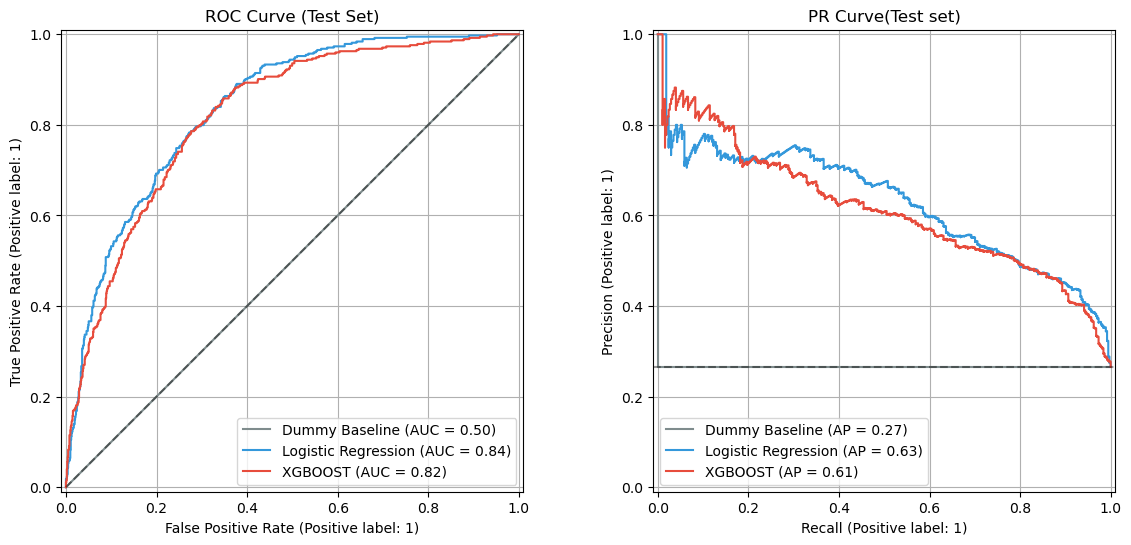

In [96]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, average_precision_score
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#7f8c8d', '#3498db', '#e74c3c']

for (name, pipe), color in zip(pipelines.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0], color=color)
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=name, color=color)



axes[0].set_title('ROC Curve (Test Set)')
axes[1].set_title('PR Curve(Test set)')
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--',alpha=0.4, label='No-skill')
axes[1].grid()
axes[0].grid()

In [97]:
rows = []
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': name, 
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC': round(average_precision_score(y_test, y_prob), 4),
        'CV ROC-AUC': f"{cv_results[name]['roc_auc_mean']:.4f} +/- {cv_results[name]['roc_auc_std']:.4f}",
        'CV PR-AUC':  f"{cv_results[name]['pr_auc_mean']:.4f} +/- {cv_results[name]['pr_auc_std']:.4f}",
    })

results_df = pd.DataFrame(rows).set_index('Model')
print('=== Model Comparison ===')
results_df


=== Model Comparison ===


,ROC-AUC,PR-AUC,CV ROC-AUC,CV PR-AUC
Model,,,,
Dummy Baseline,0.5000,0.2654,0.5000 +/- 0.0000,0.2654 +/- 0.0001
Logistic Regression,0.8387,0.6288,0.8443 +/- 0.0118,0.6565 +/- 0.0166
XGBOOST,0.8218,0.6130,0.8117 +/- 0.0073,0.5880 +/- 0.0144


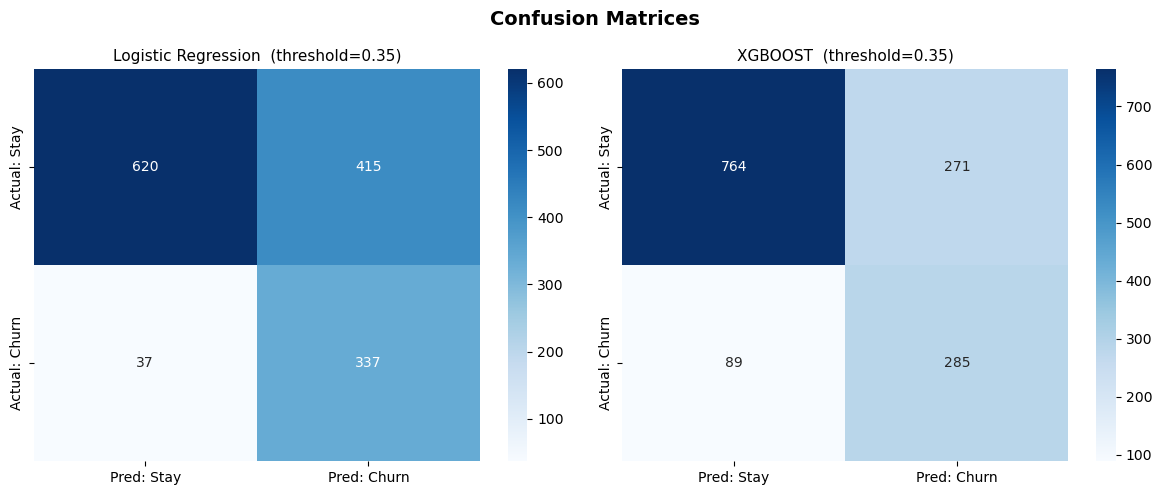

Reading the matrix (threshold=0.35):
  Top-left:     True Negatives  (correctly said stay)         -- good
  Top-right:    False Positives (stayer flagged as churner)    -- cheap mistake
  Bottom-left:  False Negatives (churner we MISSED)            -- EXPENSIVE
  Bottom-right: True Positives  (churner correctly caught)     -- good


In [98]:
# =============================================================
# CELL 18 — CONFUSION MATRIX WITH CUSTOM THRESHOLD
#
# Default classification threshold = 0.5.
# We lower it to 0.35 because:
#
#   False Negative (missing a churner) costs MORE than
#   False Positive (sending a retention offer to a non-churner).
#
# Lower threshold -> higher Recall (catch more churners)
# at the cost of slightly lower Precision (some false alarms).
# This is the correct business trade-off.
# =============================================================

THRESHOLD = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Skip the dummy classifier (index 0); compare the two real models
for ax, (name, pipe) in zip(axes, list(pipelines.items())[1:]):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)   # apply custom threshold
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Stay', 'Pred: Churn'],
                yticklabels=['Actual: Stay', 'Actual: Churn'])
    ax.set_title(f'{name}  (threshold={THRESHOLD})', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Reading the matrix (threshold={THRESHOLD}):')
print('  Top-left:     True Negatives  (correctly said stay)         -- good')
print('  Top-right:    False Positives (stayer flagged as churner)    -- cheap mistake')
print('  Bottom-left:  False Negatives (churner we MISSED)            -- EXPENSIVE')
print('  Bottom-right: True Positives  (churner correctly caught)     -- good')


In [99]:
best_pipe   = xgb_pipeline
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= THRESHOLD).astype(int)
from sklearn.metrics import classification_report
print(f'=== XGBoost Classification Report (threshold = {THRESHOLD}) ===')
print(classification_report(
    y_test, y_pred_best,
    target_names=['Retained (0)', 'Churned (1)']
))

=== XGBoost Classification Report (threshold = 0.35) ===
              precision    recall  f1-score   support

Retained (0)       0.90      0.74      0.81      1035
 Churned (1)       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.76      1409



In [102]:
ohe_feature_names = (
    best_pipe.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols_model)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

import shap

X_test_transformed = best_pipe.named_steps['prep'].transform(X_test)

explainer = shap.TreeExplainer(best_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)


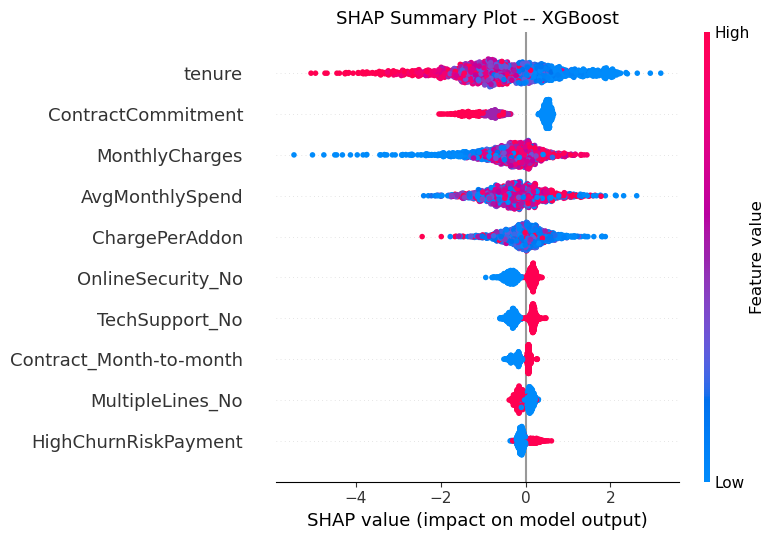

How to read this:
  tenure: low tenure (blue) on right -> high SHAP -> strong churn push
  ContractCommitment: 0 (month-to-month) pushes toward churn strongly
  MonthlyCharges: high charges (red) -> increases churn prediction
  NumAddons: more addons (red) -> LOWER churn risk (negative SHAP)


In [103]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, max_display=10, show=False)

plt.title('SHAP Summary Plot -- XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

print('How to read this:')
print('  tenure: low tenure (blue) on right -> high SHAP -> strong churn push')
print('  ContractCommitment: 0 (month-to-month) pushes toward churn strongly')
print('  MonthlyCharges: high charges (red) -> increases churn prediction')
print('  NumAddons: more addons (red) -> LOWER churn risk (negative SHAP)')


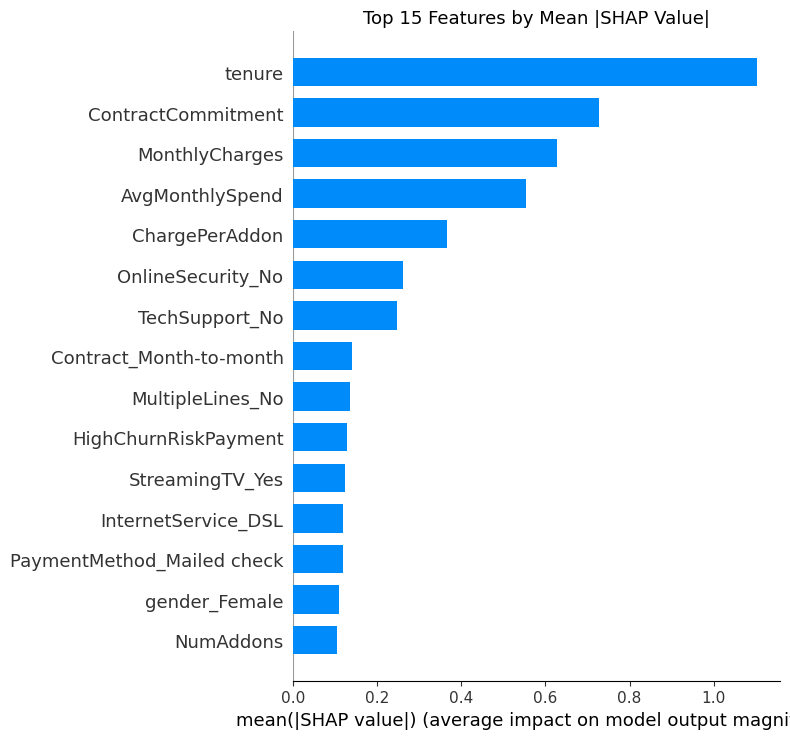

In [104]:
# =============================================================
# CELL 22 — SHAP BAR PLOT (MEAN ABSOLUTE IMPORTANCE)
#
# Simpler than the dot plot.
# Shows the average |SHAP value| per feature = overall feature importance.
# =============================================================

shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 Features by Mean |SHAP Value|', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:

X_all = df.drop(columns=DROP_COLS)
df['ChurnProbability'] = best_pipe.predict_proba(X_all)[:, 1]
df['AtRisk'] = (df['ChurnProbability'] >= THRESHOLD).astype(int)

at_risk_df  = df[df['AtRisk'] == 1]
n_at_risk   = len(at_risk_df)
mrr_at_risk = at_risk_df['MonthlyCharges'].sum()

AVG_LTV_MONTHS = 24   # assume retained customer stays 24 more months
ltv_at_risk    = mrr_at_risk * AVG_LTV_MONTHS

print(f'\nRevenue-at-Risk Summary')
print('=' * 45)
print(f'  Customers flagged at-risk:      {n_at_risk:,}')
print(f'  Monthly Revenue at risk (MRR):  ${mrr_at_risk:,.0f}')
print(f'  Lifetime Value at risk (24m):   ${ltv_at_risk:,.0f}')
print(f'\n  If we retain 30% of these customers:')
print(f'  Preserved LTV = ${ltv_at_risk * 0.30:,.0f}')

risk_by_contract = (
    at_risk_df.groupby('Contract')
    .agg(Customers=('customerID', 'count'),
         MRR=('MonthlyCharges', 'sum'),
         AvgChurnProb=('ChurnProbability', 'mean'))
    .sort_values('MRR', ascending=False)
)
risk_by_contract['MRR']          = risk_by_contract['MRR'].map('${:,.0f}'.format)
risk_by_contract['AvgChurnProb'] = risk_by_contract['AvgChurnProb'].map('{:.1%}'.format)
print('\nAt-risk breakdown by contract type:')
print(risk_by_contract)



Revenue-at-Risk Summary
  Customers flagged at-risk:      2,714
  Monthly Revenue at risk (MRR):  $200,705
  Lifetime Value at risk (24m):   $4,816,927

  If we retain 30% of these customers:
  Preserved LTV = $1,445,078

At-risk breakdown by contract type:
                Customers       MRR AvgChurnProb
Contract                                        
Month-to-month       2455  $177,628        75.9%
One year              207   $18,407        68.6%
Two year               52    $4,670        69.0%


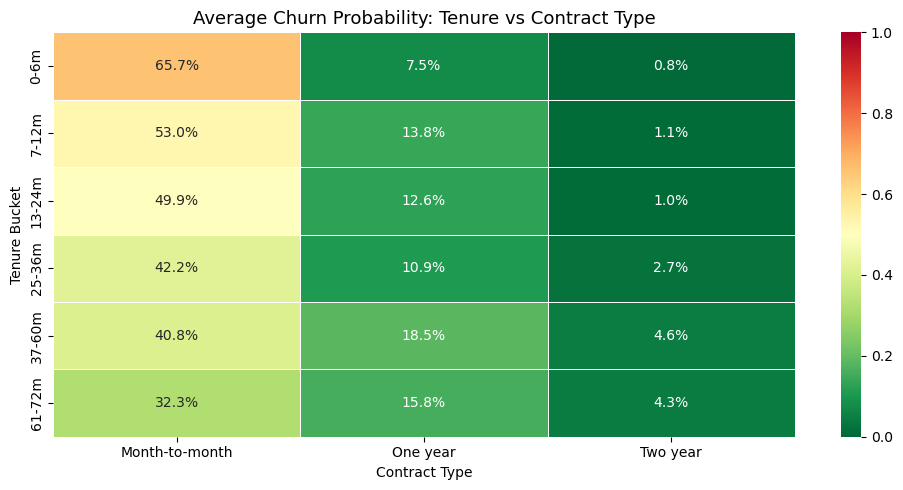

The top-left cell (0-6m + Month-to-month) = the HOT ZONE.
Brand-new, uncommitted customers. Maximum risk. Highest ROI for retention spend.


In [109]:
pivot = df.pivot_table(
    columns='Contract',
    index='TenureBucket',
    values='ChurnProbability',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Average Churn Probability: Tenure vs Contract Type', fontsize=13)
ax.set_ylabel('Tenure Bucket')
ax.set_xlabel('Contract Type')
plt.tight_layout()
plt.show()

print('The top-left cell (0-6m + Month-to-month) = the HOT ZONE.')
print('Brand-new, uncommitted customers. Maximum risk. Highest ROI for retention spend.')


In [110]:
recommendations = """
BUSINESS RECOMMENDATIONS -- TELCO CHURN PREDICTION
====================================================

1. TARGET THE 0-12 MONTH WINDOW AGGRESSIVELY
   The first year is when churn risk is highest.
   Implement an automated early-life journey:
   onboarding emails + check-in calls at 30/60/90 days.

2. CONVERT MONTH-TO-MONTH CUSTOMERS TO ANNUAL PLANS
   A 10% discount for switching to a 1-year plan
   reduces churn risk by ~70%.
   The discount cost is far less than the LTV saved.

3. PUSH ADD-ON ADOPTION (OnlineSecurity, TechSupport, etc.)
   SHAP shows NumAddons is a top retention driver.
   Run free 30-day trials. Customers who adopt add-ons
   are significantly less likely to leave.

4. MIGRATE CUSTOMERS TO AUTOPAY
   Electronic check payers churn most.
   A $5/month autopay discount reduces friction AND
   improves payment reliability. Win-win.

5. PROACTIVE OUTREACH FOR HIGH-RISK FIBER CUSTOMERS
   Fiber optic users churn more than DSL.
   Proactive speed tests and upgrade offers can
   reframe value before the customer decides to leave.

6. SCORE EVERY CUSTOMER MONTHLY -- TIERED CRM ACTIONS
   Run this model as a monthly batch job.
   Score 0.35-0.55  ->  automated email with loyalty offer
   Score 0.55-0.75  ->  targeted call from retention team
   Score > 0.75     ->  high-priority manager callback
"""
print(recommendations)



BUSINESS RECOMMENDATIONS -- TELCO CHURN PREDICTION

1. TARGET THE 0-12 MONTH WINDOW AGGRESSIVELY
   The first year is when churn risk is highest.
   Implement an automated early-life journey:
   onboarding emails + check-in calls at 30/60/90 days.

2. CONVERT MONTH-TO-MONTH CUSTOMERS TO ANNUAL PLANS
   A 10% discount for switching to a 1-year plan
   reduces churn risk by ~70%.
   The discount cost is far less than the LTV saved.

3. PUSH ADD-ON ADOPTION (OnlineSecurity, TechSupport, etc.)
   SHAP shows NumAddons is a top retention driver.
   Run free 30-day trials. Customers who adopt add-ons
   are significantly less likely to leave.

4. MIGRATE CUSTOMERS TO AUTOPAY
   Electronic check payers churn most.
   A $5/month autopay discount reduces friction AND
   improves payment reliability. Win-win.

5. PROACTIVE OUTREACH FOR HIGH-RISK FIBER CUSTOMERS
   Fiber optic users churn more than DSL.
   Proactive speed tests and upgrade offers can
   reframe value before the customer decides t